In [50]:
import numpy as np

dir = "tests/6_5.0/"
errors = np.loadtxt("{}errors.txt".format(dir))
grad_error = np.gradient(errors)
change_iters = []
for i,g in enumerate(grad_error):
    if i == 0:
        continue
    # if np.sign(g) == -1:
    #     continue
    # if abs(grad_error[i-1]-grad_error[i+1])<1e-6:
    #     continue
    # print(g)
    if abs(g)<1e-2:
        continue
    change_iters.append(i)
change_iters.append(len(errors)-2)
change_iters = np.unique(change_iters)
print(change_iters, len(change_iters))


[  1   6   7  33  34  52  53  54  55  59  60 458] 12


In [ ]:
from toolbox import manuscriptPlots
from scripts.data_processing import write_average_error, write_Q2
from scripts.data_processing import download
import numpy as np
import pandas as pd
import os

dir = "tests/6_5.0_4_cells/"
write_average_error(dir)
write_Q2(dir)
# write_Q2("tests/6_5.0_4_cells/",interval = 10)

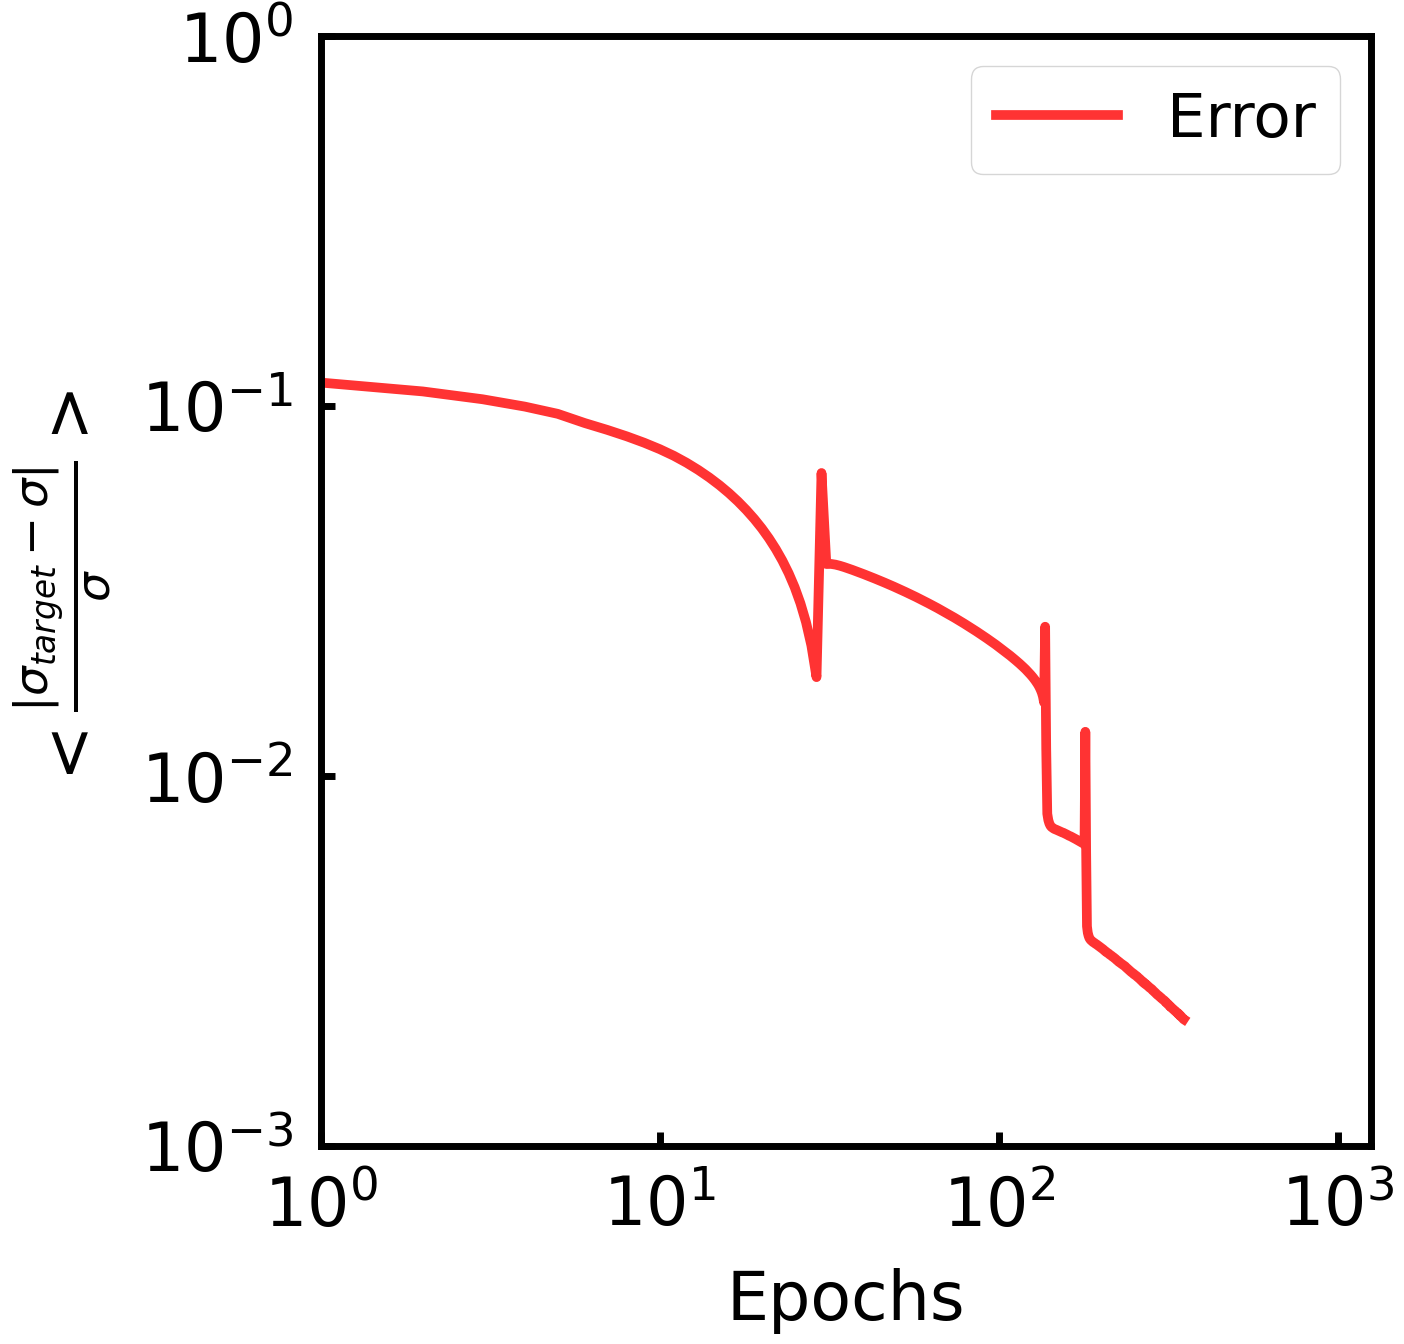

In [10]:
from toolbox import manuscriptPlots
from scripts.data_processing import write_average_error
from scripts.data_processing import download
import numpy as np
import pandas as pd
import os

dir = "tests/6_5.0/"
write_average_error(dir)

input_file = "{}errors.txt".format(dir)
plotter = manuscriptPlots.plot()
plotter.set_ylim(1e-3,1e0)

plotter.set_xlim(1,1250)

# plotter.set_title(" p = {:.2f}".format(p))
plotter.set_xlabel("Epochs")
plotter.set_ylabel(r"$<\frac{|\sigma_{target}-\sigma|}{\sigma}>$")
# plotter.set_ylabel(r"$<\sum_{cells}{|s_{0,cell}^{(A)}-s_{0,cell}^{(B)}|}>$")

plotter.set_xticks([500*i for i in range(100)])
plotter.set_yticks([0.05*i for i in range(1,10)])
plotter.set_yScaled()

plotter.initialize_figure()
plotter.ax.set_xscale("log")
plotter.ax.set_yscale("log")
errors = np.loadtxt(dir+ "errors.txt")
epochs = [i+1 for i in range(len(errors))]
plotter.plot_xy(epochs,errors,label = "Error", color= "red",alpha = 0.8)
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = r"$\sigma_{trained}<\sigma_{initial}$", color= "red",alpha = 0.8)
plotter.save_fig("{}errors.jpg".format(dir))

# df = pd.read_csv("../tvm-fire/sp_5_cell_increase/costs.csv")
# costs = df["mean"].to_numpy()
# err = df["sem"].to_numpy()
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = r"$\sigma_{trained}>\sigma_{initial}$", color= "blue",alpha = 0.8)

# df = pd.read_csv("../tvm-fire/mp_2_cells/patternA_costs.csv")
# costs = df["mean"].to_numpy()
# err = df["sem"].to_numpy()
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = "Pattern A", color= "red",alpha = 0.6)

# df = pd.read_csv("../tvm-fire/mp_2_cells/patternB_costs.csv")
# costs = df["mean"].to_numpy()
# err = df["sem"].to_numpy()
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = "Pattern B", color= "blue",alpha = 0.6)

# df = pd.read_csv("../tvm-fire/mp_2_cells/distances.csv")
# costs = df["mean"].to_numpy()
# err = df["sem"].to_numpy()
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = "_Pattern A", color= "black",alpha = 0.6)

# plotter.save_fig("/Users/shabeebameen/Projects/tvm-fire/mp_2_cells_distances.jpg")


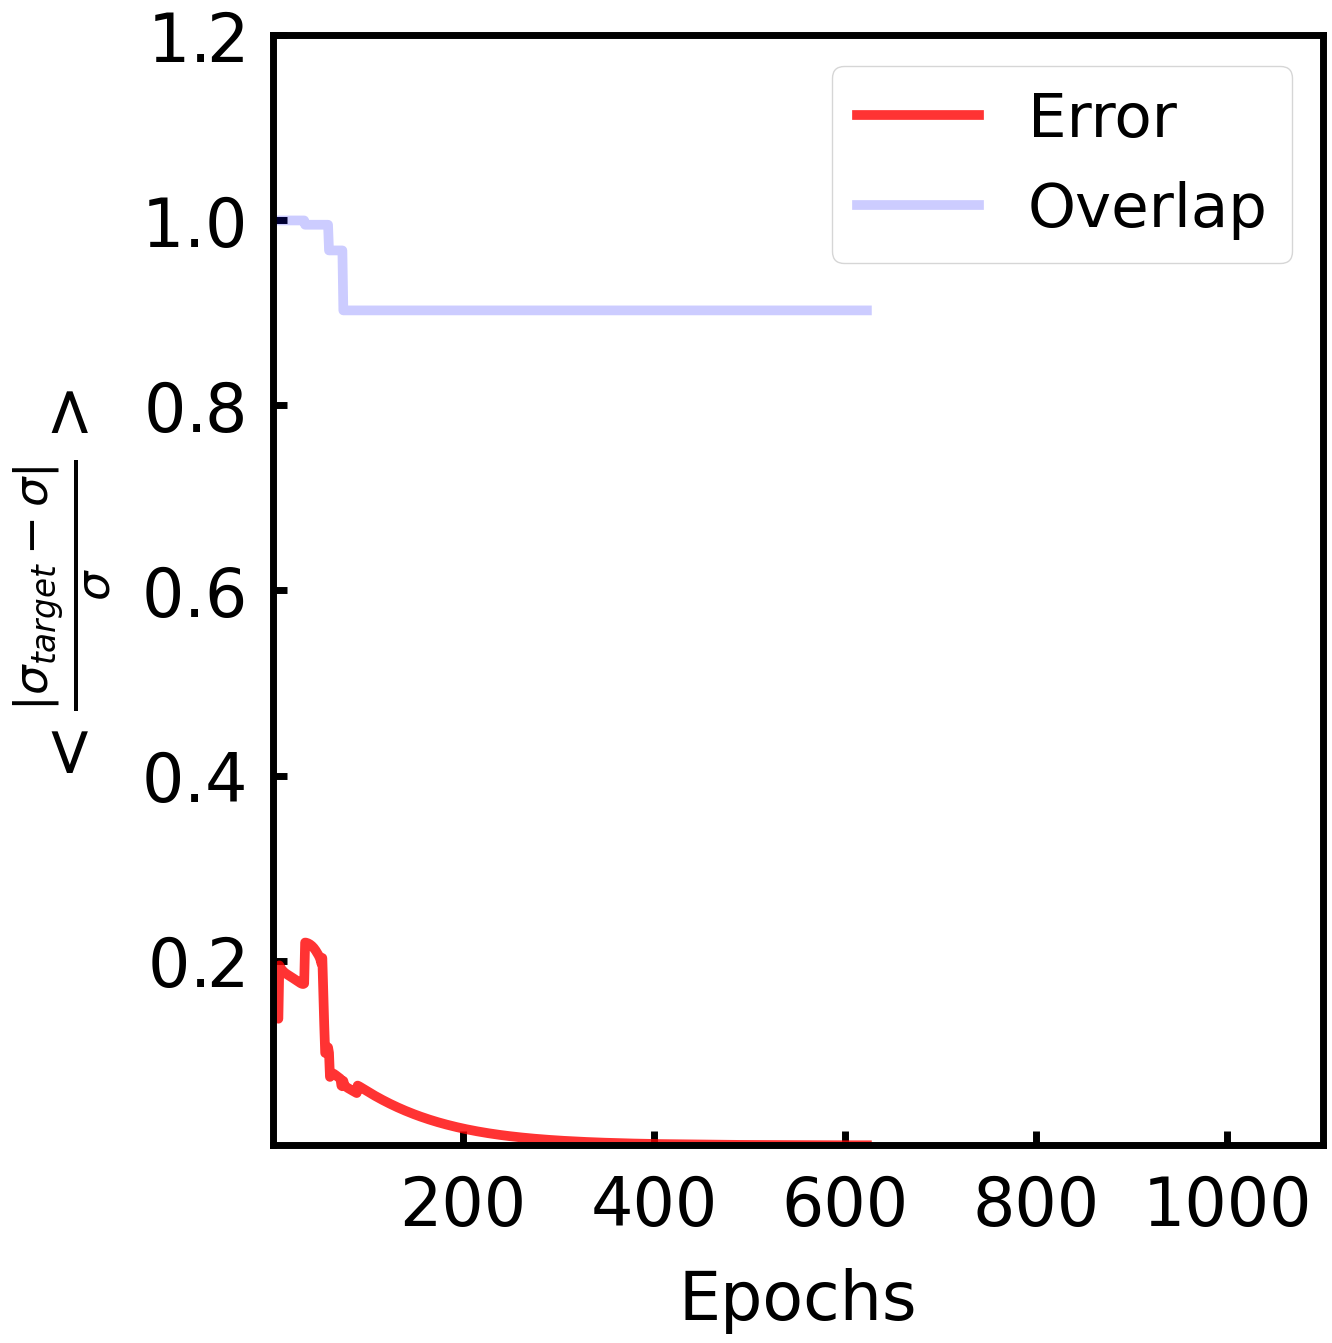

In [3]:
from toolbox import manuscriptPlots
from scripts.data_processing import write_average_error
from scripts.data_processing import download
import numpy as np
import pandas as pd
import os

dir = "tests/6_5.0/"
input_file = "{}overlaps.csv".format(dir)
df = pd.read_csv(input_file)
plotter = manuscriptPlots.plot()
plotter.set_ylim(1e-4,1.2)
plotter.set_xlim(1,1100)
# plotter.set_title(" p = {:.2f}".format(p))
plotter.set_xlabel("Epochs")
plotter.set_ylabel(r"$<\frac{|\sigma_{target}-\sigma|}{\sigma}>$")
# plotter.set_ylabel(r"$<\sum_{cells}{|s_{0,cell}^{(A)}-s_{0,cell}^{(B)}|}>$")

plotter.set_xticks([200*i for i in range(2000)])
plotter.set_yticks([0.2*i for i in range(1,10)])
plotter.set_yScaled()

plotter.initialize_figure()
# plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
# plotter.set_yLog()
errors = np.loadtxt(dir+ "errors.txt")
epochs = [i+1 for i in range(len(errors))]
plotter.plot_xy(epochs,errors,label = "Error", color= "red",alpha = 0.8)
overlaps = np.loadtxt(dir+ "overlaps.txt")
plotter.plot_xy(epochs,overlaps,label = "Overlap", color= "blue",alpha = 0.2)
# grads = np.gradient(overlaps)
# for i,g in enumerate(grads):
#     # print(g)
#     if i ==0:
#         continue
#     if i==len(overlaps):
#         continue
#     if g == 0 and grads [i-1]== 0:
#         continue
#     if abs(g-grads [i-1]) <5e-3:
#         continue
#     plotter.ax.vlines(epochs[i], ymin = 0, ymax = 2,linestyles= "--", colors = 'purple',alpha = 0.3)

# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = r"$\sigma_{trained}<\sigma_{initial}$", color= "red",alpha = 0.8)
plotter.save_fig("{}overlaps.jpg".format(dir))

